# Classification with Amazon SageMaker
_**Single machine training for classification with Amazon SageMaker various algorithm**_


---
## Introduction

This notebook demonstrates the use of Amazon SageMaker’s implementation of the various classification algorithm to train. 



In [15]:
import boto3
import io
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv), data manipulation as in SQL

import matplotlib.pyplot as plt # this is used for the plot the graph
import seaborn as sns # used for plot interactive graph. I like it most for plot

s3 = boto3.client('s3')
obj = s3.get_object(Bucket='betterml', Key='machine-learning/2020/01/breast-cancer-data.csv')
dataframe = pd.read_csv(io.BytesIO(obj['Body'].read()), skipinitialspace = True, thousands=',')
dataframe.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
import boto3
import io
import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv), data manipulation as in SQL

import matplotlib.pyplot as plt # this is used for the plot the graph
import seaborn as sns # used for plot interactive graph. I like it most for plot
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import Imputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split # to split the data into two parts

#Classification Models
from sklearn.linear_model import LogisticRegression # to apply the Logistic regression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC, NuSVC
from sklearn.naive_bayes import GaussianNB

#Classification metrics
from sklearn import metrics # for the check the error and accuracy of the model
from sklearn.metrics import accuracy_score, log_loss, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

def warn(*args, **kwargs): pass
import warnings
warnings.warn = warn

def read_analyze_data(file):
    try:
        print("****read_analyze_data****")
        #dirlog = '../Log/'
        #dataframe = pd.read_csv(file, skipinitialspace = True, thousands=',')
        s3 = boto3.client('s3')
        obj = s3.get_object(Bucket='betterml', Key='machine-learning/2020/01/breast-cancer-data.csv')
        dataframe = pd.read_csv(io.BytesIO(obj['Body'].read()), skipinitialspace = True, thousands=',')
        dataframe.head()
        print("***Exploratory Data Analysis***")
        print("****Top 5 rows***")
        #dfhtml = dataframe.head().style.set_properties(**{'background-color': 'black','color': 'lawngreen','border-color': 'white'}).hide_index().render()
        dfhtml = dataframe.head()

        html = dfhtml.to_html()

        print(dataframe.head())
        print("****Last 5 rows***")
        print(dataframe.tail())
        print("****dataframe shape***")
        print(dataframe.shape)
        print("****dataframe info***")
        print(dataframe.info())
        print("****data frame describe statistics***")
        print(dataframe.describe())
        print("****data frame column sums ***")
        print(dataframe.sum())
        # check any null values in the DF
        print("****dataframe check nulls***")
        print(pd.isnull(dataframe).any())
        print("****dataframe check column nulls count***")
        print(dataframe.isna().sum())
        # check non unique values, helps in lable encoding, onehot encoding or pandas dummy columns
        print("****dataframe check non unique***")
        print(dataframe.nunique())
        print("****dataframe columns***")
        print(dataframe.columns)
        print("****delete complete null columns")
    

    
        # find lable column
        dataframe.select_dtypes(include=[object])
        
    except:
         print("An exception occurred in read_analyze_data")
    return dataframe,html

def scale_data_minmax(dataframe):
    try:
        #explore StandardScalara, minmaxscaler etc
        print("****scale_data min max 0 and 1 ****'")
        scaler = MinMaxScaler(feature_range=[0, 1])
        scaler = scaler.fit_transform(dataframe)
        #dataframe = pd.DataFrame(dataframe,columns=columnnames)
        scaler = pd.DataFrame(scaler)
        scaler.columns = dataframe.columns
        dataframe = scaler
    except:
        print("An exception occurred in scale_data_minmax")
    return dataframe

def scale_data_StandardScalar(dataframe):
    try:
        #explore StandardScalara, minmaxscaler etc
        print("****scale_data standard ****'")
        scaler = StandardScaler()
        scaler = scaler.fit_transform(dataframe)
        scaler = pd.DataFrame(scaler)
        scaler.columns = dataframe.columns
        dataframe = scaler
    except:
        print("An exception occurred in scale_data_StandardScalar")
    return dataframe
    

def half_masked_corr_heatmap(dataframe, title=None, file=None):
    try:
        print("plot heatmap")
        #image_directory = "./static/images/"
        image_directory = ""
        # Required parameter: dataframe ... the reference pandas dataframe
        # Optional parameters: title ... (string) chart title
        #                      file  ... (string) path+filename if you want to save image
        plt.figure(figsize=(14,14))
        sns.set(font_scale=1)

        mask = np.zeros_like(dataframe.corr())
        mask[np.triu_indices_from(mask)] = True

        with sns.axes_style("white"):
            sns.heatmap(dataframe.corr(), mask=mask, annot=False, cmap='coolwarm')

        if title: plt.title(f'\n{title}\n', fontsize=18)
        plt.xlabel('')    # optional in case you want an x-axis label
        plt.ylabel('')    # optional in case you want a  y-axis label
        #if file: plt.savefig(image_directory+file, bbox_inches='tight')
        plt.show();
        plt.clf()
    except:
        print("An exception occurred in half_masked_corr_heatmap")
    
    return

def plot_boxplot(dataframe, title=None, file=None):
    try:
        print("plot box plot")
        #image_directory = "./static/images/"
        image_directory = ""
        # Required parameter: dataframe ... the reference pandas dataframe
        # Optional parameters: title ... (string) chart title
        #                      file  ... (string) path+filename if you want to save image
        plt.figure(figsize=(14,6))
        dfbox = scale_data_minmax(dataframe)
        ax = sns.boxplot(data=dfbox, orient="v", palette="Set2")
        plt.setp(ax.get_xticklabels(), rotation=90)
        if title: plt.title(f'\n{title}\n', fontsize=18)

        #if file: plt.savefig(file, bbox_inches='tight')
        if file: 
            plt.savefig(image_directory+file, dpi=None, facecolor='w', edgecolor='w',
            orientation='portrait', papertype=None, format=None,
            transparent=False, bbox_inches='tight', pad_inches=0.1,
            frameon=None, metadata=None)

        plt.show()
        plt.clf()    


        #plt.figure(figsize=(14, 6))
        #ax = sns.boxplot(data=dfbox, orient="v", palette="Set2")
        #plt.setp(ax.get_xticklabels(), rotation=90)
        #plt.show()
    except:
        print("An exception occurred in plot_boxplot")
    
    return 

def plot_countplot(dataframe,title=None,file=None): 
    try:
        print("plot count plot")
        #image_directory = "./static/images/"
        image_directory = ""
        for column in dataframe.columns:
            print("in column loop",column)
            sns.countplot(x = column , data = dataframe, label="Count")
            """if file: 
                plt.savefig(image_directory+file+column, dpi=None, facecolor='w', edgecolor='w',
                orientation='portrait', papertype=None, format=None,
                transparent=False, bbox_inches='tight', pad_inches=0.1,
                frameon=None, metadata=None)
                plt.clf()"""


            plt.show()
            #for column in dfcategorical.columns:
            #print("in column loop",column)
            #sns.countplot(x = column , data = dfcategorical, label="Count")
            #plt.show()
    except:
        print("An exception occurred in plot_countplot")

       
    return 

def plot_analysis_data(dfwolables, dfcategorical):
    try:
        print("****plot_analysis_data****'")
        labl = list(dfwolables.columns)
        print("lables",labl)

        # scale(lognormal) data to keep every number between 0 and 1
        # box plot requires all features in same scale to plot together
        print(dfwolables.columns.values)
        dfbox = scale_data_minmax(dfwolables)


        #Boxplot to analyze the statistical parameters,outliers and distribution
        #plt.figure(figsize=(14, 6))
        #ax = sns.boxplot(data=dfbox, orient="v", palette="Set2")
        #plt.setp(ax.get_xticklabels(), rotation=90)
        #plt.show()

        plot_boxplot(dfbox,'Variables Boxplot','box')

        # plot the data 
        ## Heatmap to check the correlation between features
        #corr = dfwolables.corr() # .corr is used for find corelation
        #plt.figure(figsize=(14,14))
        #sns.heatmap(corr,cbar = True,square = True,cmap= 'coolwarm')
        #plt.show()
        half_masked_corr_heatmap(dfwolables,'Variable Correlations','heatmap')


        ## Pairpolot to see the correlation using scatter plots
        #corr = dfwolables.corr() # .corr is used for find corelation bw features
        #sns.pairplot(corr)
        #plt.show()

        plot_countplot(dfcategorical,'Lable Count Plot','countplot')   
        #for column in dfcategorical.columns:
        #    print("in column loop",column)
        #    sns.countplot(x = column , data = dfcategorical, label="Count")
        #    plt.show()
    except:
        print("An exception occurred in plot_analysis_data")    
        
    return 

def convert_data_numerical_categorical(dataframe):
    print("****convert data to numerical and Categorical dataframes ****'")
    #Check the categorical data(nominal or ordinal)
    dfcategorical = dataframe.select_dtypes(include=[object])
    
    #Check the numerical data(discrete or continuous)
    #dataframe = dataframe.select_dtypes(exclude=['object'])
    dfnumeric = dataframe.select_dtypes(exclude=['object'])
    
    #dataframelabel = dataframe.select_dtypes(include=['object'])
    return dfcategorical, dfnumeric

    #def check_data_lables(dataframe):
    #Drop rows with nulls
    #Drop column with complete nulls
    #df = df.dropna(axis = 0, how = 'any')
    #Find duplicates data
    #repeat_patients = df.groupby(by = 'patient_id').size().sort_values(ascending =False)
    #Filter rows more than 2 times
    #filtered_patients = repeat_patients[repeat_patients > 2].to_frame().reset_index()
    #filtered_df = df[~df.patient_id.isin(filtered_patients.patient_id)]

def impute_nulls_data(dataframe):
    print("****impute_nulls_data****'")
    imp = Imputer(missing_values="NaN",strategy="mean",axis =0) #check the strategy options strategy="most_frequent"
    dfencodeimpute = imp.fit_transform(dataframe)
    dfencodeimpute = pd.DataFrame(dfencodeimpute)
    dfencodeimpute.columns = dataframe.columns
    dataframe = dfencodeimpute
    #from sklearn.impute import SimpleImputer(univariate), IterativeImputer(multivariate)
    #Explore Univariate vs. Multivariate Imputation
    return dataframe

def encode_data(dataframe): #sklean Label encoder, onehot encoding, pandas dummy
    print("****encode_data****'")
    try:
        # Note : lable encoding 
        print(dataframe.head())
        print(dataframe.columns)
        #data['diagnosis']=data['diagnosis'].map({'M':1,'B':0})
        columnlist = list(dataframe.columns)
        enc = LabelEncoder()
        for column in columnlist:
            if (dataframe[column].nunique() <= 2 or dataframe[column].nunique() > 50 ):
                #binary encoding
                enc.fit(dataframe[column])
                print(column)
                columnenc = column + "_encoded"
                dataframe[columnenc] = enc.transform(dataframe[column])
                dataframe.drop([column], axis = 1,inplace = True)
            else:
                #onehot, dummy encoding
                # Get dummies
                dataframe = pd.get_dummies(dataframe[column], prefix_sep='_', drop_first=True)
                dataframe.head()
                

        print(dataframe.head())
        #dfencoded = pd.concat([dfnumeric,dfcategorical],axis = 1)
        #print(dfencoded.head())
    except:
         print("An exception occurred in encode")

    return dataframe


def exploratorydataanalysis(chat_in):
    try:
        print("here:",chat_in)

        file = 'breast-cancer-data.csv'

        predictmodel = 'classification'
        # Find the input file


        # 1. Exploratory Data Analysis EDA
        #print("here2:",dir+chat_in)
        dforig, html = read_analyze_data(file)
        print(html)
        #html = html.replace('dataframe','table table-responsive',1)
        dfcategorical, dfwolables = convert_data_numerical_categorical(dforig)

        plot_analysis_data(dfwolables, dfcategorical)

        text_file = open("index.html", "w")
        text_file.write(html)
        text_file.close()
    except:
         print("An exception occurred in exploratorydataanalysis")
    

    return html
def data_wangling(dforig):
    try:
        # 3. Data Wrangling/ preprocessing  ####
        # Note : lable encoding categorical data 
        print("****drop complete null value columns")
        dforig.dropna(axis = 1,how='all', inplace = True)
        print("****delete complete null rows")
        dforig.dropna(axis=0, how='all', inplace=True)
        print("****Remove duplicate rows")
        dupes = dforig.duplicated()
        print("remove duplicate number of rows:\n",sum(dupes))
        #Removing Duplicates
        dforig = dforig.drop_duplicates()
        # Remove rows where label column is null
        print("remove label column value is null\n")
        #???dforig = dforig[dforig[labelcolumn].notnull()]
        print(dforig.head())

        #convert Date to Date and time
        # Converts date string column to python datetime type
        # `infer_datetime_format=True` says method to guess date format from string
        #df['datetime'] = pd.to_datetime(df['date_string'], infer_datetime_format=True)
        # Converts date string column to python datetime type
        # `format` argument specifies the format of date to parse, fails on errors
        #df['datetime'] = pd.to_datetime(df['date_string'], format='%Y.%m.%d')

        # Coverts column in python datetime type to timestamp
        #df['timestamp'] = df['datetime'].values.astype(np.int64) // 10 ** 9


        #Remove white spaces
        #Make sure integers are not float or character
        # Convert data to numerical and categorical dataframes
        dfcategorical, dfnumeric = convert_data_numerical_categorical(dforig)
        dfwolables = dfnumeric
        print("Numeric data:\n",dfwolables.head())
        print("Categorical data:\n",dfcategorical.head())

        #impute_nulls_data numerical data
        dfnumericimpute = impute_nulls_data(dfnumeric)
        # we can also use KNN to propogate null values in the columns


        # encode categorical data
        dfcategoricalencode = encode_data(dfcategorical)  
        # If cetegorical feature is  null will be encoded to 0 etc

        #scale data normalize data (reduce the impact of outliers)
        dfv = scale_data_StandardScalar(dfnumericimpute)
        dfv.head()
        # join encoded and numeric data
        dfv = pd.concat([dfv,dfcategoricalencode],axis = 1)
    
    except:
         print("An exception occurred in data_wangling")    

    
    return dfv


def split_data(dataframe):
    try:
        print("****split_data****'")
        # split X and y data
        X = dataframe.iloc[:,0:-1]
        X
        y = dataframe.iloc[:,-1]
        y
        # Train Test Split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=5) # 80% training and 20% test
        print("X_train:" + str(X_train.shape))
        print("X_test:" + str(X_test.shape))
        print("y_train:" + str(y_train.shape))
        print("y_test:" + str(y_test.shape))
        print("y_train",y_train)

        #sss = StratifiedShuffleSplit(labels, 10, test_size=0.2, random_state=23)
        #for train_index, test_index in sss:
        #    X_train, X_test = train.values[train_index], train.values[test_index]
        #    y_train, y_test = labels[train_index], labels[test_index]
    except:
         print("An exception occurred in split_data")  
    
    return X_train, X_test, y_train, y_test

# fit different classificatin models 
def fit_data_model(X_train, X_test, y_train, y_test):
    try:
        print("****fit_data_model****'")
        classifiers = [
            LogisticRegression(),
            KNeighborsClassifier(3),
            SVC(kernel="rbf", C=0.025, probability=True),
            NuSVC(probability=True),
            DecisionTreeClassifier(),
            RandomForestClassifier(),
            GaussianNB()]
        # Logging for Visual Comparison
        log_cols=["Classifier", "Accuracy", "Log Loss", "Pricision", "Recall", "f1 Score"]
        logdf = pd.DataFrame(columns=log_cols)

        for clf in classifiers:
            clf.fit(X_train, y_train)
            name = clf.__class__.__name__

            print("="*30)
            print(name)

            print("****Results****'")
            y_predict = clf.predict(X_test)
            acc = accuracy_score(y_test, y_predict)
            print("Accuracy: {:.4%}".format(acc))

            report = classification_report(y_test, y_predict)
            print(report)

            matrix = confusion_matrix(y_test, y_predict)
            print(matrix)
            confusion_df = pd.DataFrame(confusion_matrix(y_test,y_predict),
            columns=["Predicted Class " + str(class_name) for class_name in [0,1]],
            index = ["Class " + str(class_name) for class_name in [0,1]])
            print(confusion_df)


            #curve = precision_recall_curve(y_test, y_predict)
            #plt.plot(curve)
            pc = precision_score(y_test,y_predict)
            print("Precision: {}".format(pc))

            rc = recall_score(y_test,y_predict)
            print("Recall: {}".format(rc))
            f1 = f1_score(y_test,y_predict)
            print("f1 score: {}".format(f1))



            y_predict = clf.predict_proba(X_test)
            ll = log_loss(y_test, y_predict)
            print("Log Loss: {}".format(ll))



            log_entry = pd.DataFrame([[name, acc, ll, pc, rc, f1]], columns=log_cols)
            logdf = logdf.append(log_entry)

        print("="*30)
        
    except:
         print("An exception occurred in fit_data_model") 
    
    return logdf

def make_classification(chat_in):
    try:
        file = chat_in
        #dataframe = pd.read_csv(file, skipinitialspace = True, thousands=',')
        s3 = boto3.client('s3')
        obj = s3.get_object(Bucket='betterml', Key='machine-learning/2020/01/breast-cancer-data.csv')
        dataframe = pd.read_csv(io.BytesIO(obj['Body'].read()), skipinitialspace = True, thousands=',')
        dataframe.head()
        
        dfv = data_wangling(dataframe)
        #split data
        X_train, X_test, y_train, y_test = split_data(dfv)
        logdf = fit_data_model(X_train, X_test, y_train, y_test)
        print(logdf)
    except:
        print("An exception occurred in make_classification")

    return

here: breast-cancer-data.csv
****read_analyze_data****
***Exploratory Data Analysis***
****Top 5 rows***
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.1328

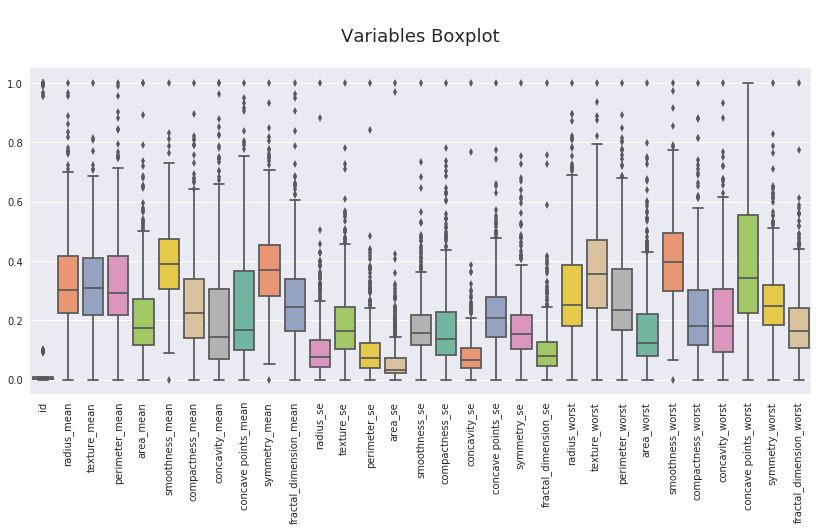

plot heatmap


<Figure size 432x288 with 0 Axes>

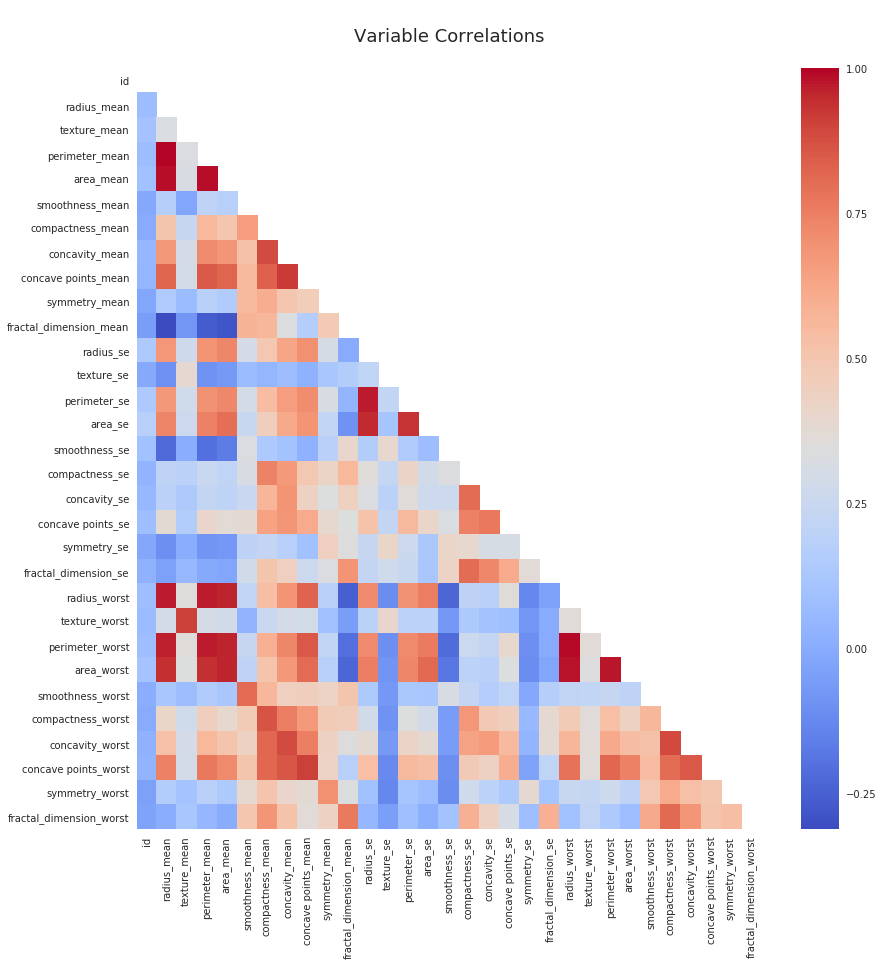

plot count plot
in column loop diagnosis


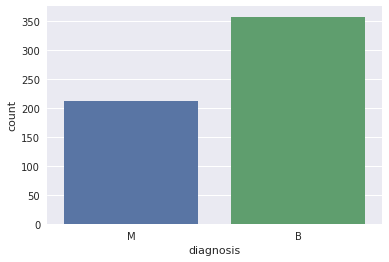

****drop complete null value columns
****delete complete null rows
****Remove duplicate rows
remove duplicate number of rows:
 0
remove label column value is null

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414 

/home/ec2-user/anaconda3/envs/python3/lib/python3.6/site-packages/sklearn/ensemble/forest.py:246: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)


In [5]:

if __name__ == '__main__':

    chat_in = 'breast-cancer-data.csv'
    X_input = exploratorydataanalysis(chat_in)
    make_classification(chat_in)

